# Model Training — Distributed DNN for Fire Severity Classification

**Pipeline:** Parquet (individual columns) → Pandas → sklearn StandardScaler → `tf.data.Dataset` → MultiWorker DNN → Evaluation → SavedModel

In [3]:
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

sys.path.append(os.path.abspath('..'))
from config import *

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
warnings.filterwarnings('ignore')
print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.19.0


---
## 1. Distributed Strategy

In [4]:
strategy = tf.distribute.MultiWorkerMirroredStrategy()
print(f'Workers in sync: {strategy.num_replicas_in_sync}')
print(f'Devices: {tf.config.list_physical_devices()}')

INFO:tensorflow:Using MirroredStrategy with devices ('/device:CPU:0',)
INFO:tensorflow:Single-worker MultiWorkerMirroredStrategy with local_devices = ('/device:CPU:0',), communication = CommunicationImplementation.AUTO
Workers in sync: 1
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


---
## 2. Load Preprocessed Data

In [5]:
data_dir = 'processed_data'

import glob
def read_csv_dir(path):
    files = sorted(glob.glob(os.path.join(path, 'part-*.csv')))
    return pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

train_pdf = read_csv_dir(os.path.join(data_dir, 'train'))
val_pdf   = read_csv_dir(os.path.join(data_dir, 'val'))
test_pdf  = read_csv_dir(os.path.join(data_dir, 'test'))

print(f'Train: {train_pdf.shape}')
print(f'Val:   {val_pdf.shape}')
print(f'Test:  {test_pdf.shape}')

Train: (1281321, 17)
Val:   (183401, 17)
Test:  (366223, 17)


In [6]:
# Separate features and target
X_train_raw = train_pdf[FEATURE_COLS].values.astype(np.float32)
y_train = train_pdf[TARGET_COL].values.astype(np.int32)

X_val_raw = val_pdf[FEATURE_COLS].values.astype(np.float32)
y_val = val_pdf[TARGET_COL].values.astype(np.int32)

X_test_raw = test_pdf[FEATURE_COLS].values.astype(np.float32)
y_test = test_pdf[TARGET_COL].values.astype(np.int32)

In [7]:
# Fit scaler on training set only, transform all splits
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)
X_test  = scaler.transform(X_test_raw)

print(f'Feature dim: {X_train.shape[1]}')

Feature dim: 15


### 2.1 Class Weights (inverse-frequency)

In [8]:
classes, counts = np.unique(y_train, return_counts=True)
n_samples = len(y_train)
class_weight_dict = {
    int(cls): n_samples / (NUM_CLASSES * cnt)
    for cls, cnt in zip(classes, counts)
}
for cls, cnt in zip(classes, counts):
    print(f'Class {CLASS_NAMES[cls]} (idx={cls}): count={cnt:>8,}  weight={class_weight_dict[int(cls)]:.4f}')

Class A (idx=0): count= 177,796  weight=1.0295
Class B (idx=1): count= 187,571  weight=0.9759
Class C (idx=2): count= 310,716  weight=0.5891
Class D (idx=3): count=  52,406  weight=3.4928
Class E (idx=4): count= 179,790  weight=1.0181
Class F (idx=5): count= 183,316  weight=0.9985
Class G (idx=6): count= 189,726  weight=0.9648


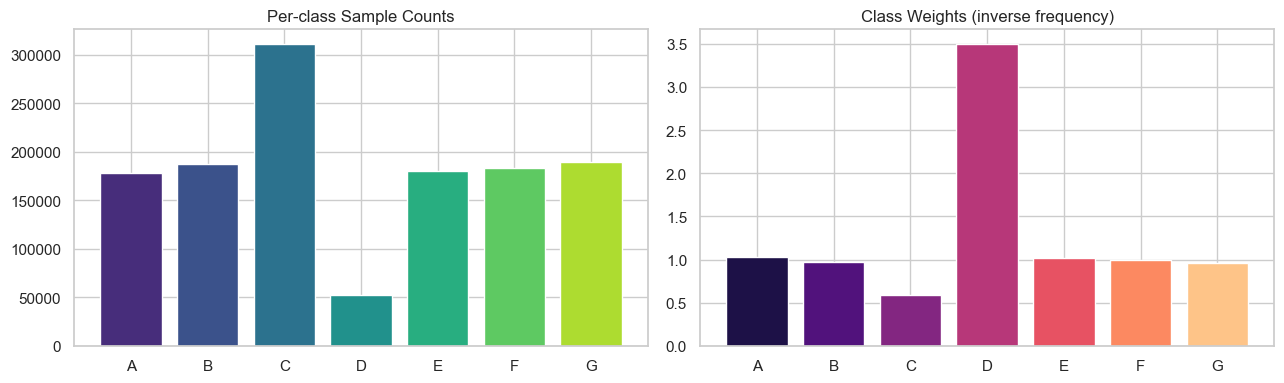

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(CLASS_NAMES, counts, color=sns.color_palette('viridis', NUM_CLASSES))
axes[0].set_title('Per-class Sample Counts')
axes[1].bar(CLASS_NAMES, [class_weight_dict[i] for i in range(NUM_CLASSES)],
            color=sns.color_palette('magma', NUM_CLASSES))
axes[1].set_title('Class Weights (inverse frequency)')
plt.tight_layout()
plt.show()

### 2.2 tf.data Dataset Pipeline

In [10]:
AUTO = tf.data.AUTOTUNE

def make_ds(X, y, batch_size, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((X.astype(np.float32), y))
    if shuffle:
        ds = ds.shuffle(10000, seed=SEED)
    return ds.batch(batch_size, drop_remainder=False).prefetch(AUTO)

train_ds = make_ds(X_train, y_train, BATCH_SIZE, shuffle=True)
val_ds   = make_ds(X_val,   y_val,   BATCH_SIZE * 2, shuffle=False)
test_ds  = make_ds(X_test,  y_test,  BATCH_SIZE * 2, shuffle=False)

---
## 3. DNN Architecture (built inside strategy scope)

In [11]:
def build_dnn(input_dim, num_classes, layers, dropout_rate):
    inputs = keras.Input(shape=(input_dim,), name='weather_features')
    x = inputs
    for units in layers:
        x = keras.layers.Dense(units, kernel_initializer='he_normal')(x)
        x = keras.layers.BatchNormalization()(x)
        x = keras.layers.ReLU()(x)
        x = keras.layers.Dropout(dropout_rate)(x)
    outputs = keras.layers.Dense(num_classes, activation='softmax', name='class_probs')(x)
    return keras.Model(inputs=inputs, outputs=outputs, name='fire_severity_dnn')

with strategy.scope():
    model = build_dnn(len(FEATURE_COLS), NUM_CLASSES, DNN_LAYERS, DROPOUT_RATE)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=['sparse_categorical_accuracy'],
    )

model.summary()

Model: "fire_severity_dnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ weather_features (InputLayer)   │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probs (Dense)             │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,495 (185.53 KB)

 Trainable params: 46,599 (182.03 KB)

 Non-trainable params: 896 (3.50 KB)

---
## 4. Training

In [12]:
callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    keras.callbacks.TensorBoard(log_dir='logs/fire_severity'),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=2,
)


Epoch 1/50
626/626 - 36s - 58ms/step - loss: 1.6075 - sparse_categorical_accuracy: 0.4189 - val_loss: 1.5255 - val_sparse_categorical_accuracy: 0.5150 - learning_rate: 1.0000e-03
Epoch 2/50
626/626 - 27s - 44ms/step - loss: 1.5408 - sparse_categorical_accuracy: 0.4637 - val_loss: 1.5736 - val_sparse_categorical_accuracy: 0.5707 - learning_rate: 1.0000e-03
Epoch 3/50
626/626 - 22s - 35ms/step - loss: 1.5140 - sparse_categorical_accuracy: 0.4780 - val_loss: 1.5870 - val_sparse_categorical_accuracy: 0.5959 - learning_rate: 1.0000e-03
Epoch 4/50
626/626 - 23s - 37ms/step - loss: 1.4787 - sparse_categorical_accuracy: 0.4899 - val_loss: 1.5916 - val_sparse_categorical_accuracy: 0.5905 - learning_rate: 1.0000e-03
Epoch 5/50
626/626 - 23s - 37ms/step - loss: 1.4167 - sparse_categorical_accuracy: 0.5103 - val_loss: 1.5992 - val_sparse_categorical_accuracy: 0.5955 - learning_rate: 1.0000e-03
Epoch 6/50
626/626 - 31s - 50ms/step - loss: 1.3536 - sparse_categorical_accuracy: 0.5317 - val_loss: 1.

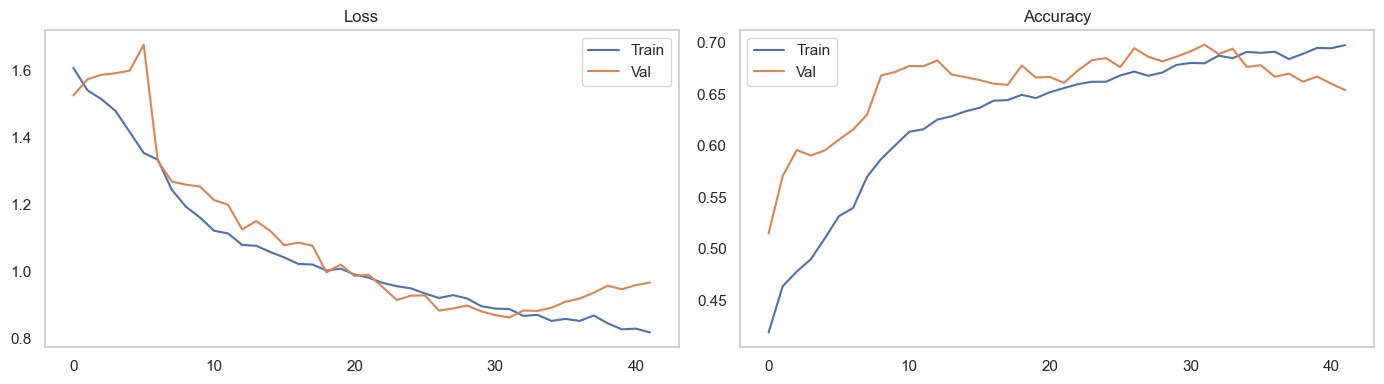

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid()
axes[1].plot(history.history['sparse_categorical_accuracy'], label='Train')
axes[1].plot(history.history['val_sparse_categorical_accuracy'], label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid()
plt.tight_layout()
plt.show()

---
## 5. Evaluation

In [14]:
y_pred_probs = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

              precision    recall  f1-score   support

           A     0.8755    0.8239    0.8489     50693
           B     0.5349    0.2183    0.3101     53470
           C     0.6454    0.7595    0.6978     89211
           D     0.1581    0.2440    0.1919     14915
           E     0.7140    0.8434    0.7733     51276
           F     0.7249    0.8724    0.7919     52596
           G     0.9081    0.7529    0.8233     54062

    accuracy                         0.6954    366223
   macro avg     0.6516    0.6449    0.6339    366223
weighted avg     0.7011    0.6954    0.6841    366223



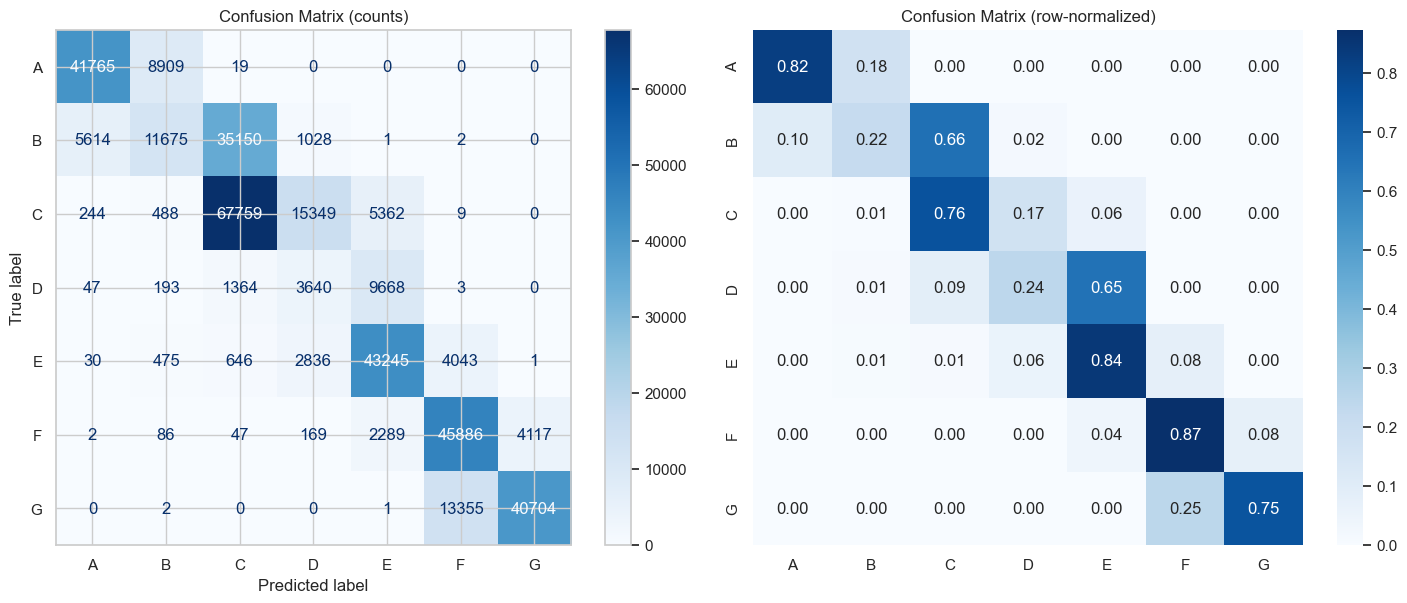

In [15]:
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title('Confusion Matrix (counts)')
sns.heatmap(cm.astype('float') / cm.sum(axis=1, keepdims=True), annot=True, fmt='.2f',
            cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix (row-normalized)')
plt.tight_layout()
plt.show()

---
## 6. Save Model

In [16]:
model_dir = 'saved_model'
os.makedirs(model_dir, exist_ok=True)
model.save(os.path.join(model_dir, 'fire_severity_model.keras'))
model.export(os.path.join(model_dir, '1'))
print(f'Model saved to {model_dir}/')

INFO:tensorflow:Assets written to: saved_model\1\assets


INFO:tensorflow:Assets written to: saved_model\1\assets


Saved artifact at 'saved_model\1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 15), dtype=tf.float32, name='weather_features')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  2184486481424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2184486483728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2184486484304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2184486484112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2184486482768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2184486483536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2184486483152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2184486485072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2184486485648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2184486482960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2184486483344: TensorSpec(shape=(), dtype=

In [17]:
del train_ds, val_ds, test_ds
print('Done.')

Done.
